In [2]:
!pip install gdown
url = 'https://docs.google.com/spreadsheets/d/1WUywPr_TxlUfPGVyMF0I2ALxXiHAyknKoZ3X13kKrUI/edit?gid=215508619#gid=215508619'

In [5]:
import gdown

# Replace with your actual Google Sheet ID
sheet_id = "1WUywPr_TxlUfPGVyMF0I2ALxXiHAyknKoZ3X13kKrUI"
# Optionally: specify the sheet/tab number (gid=0 for the first sheet)
gid = "215508619"

# Construct export URL
url = f"https://docs.google.com/spreadsheets/d/{sheet_id}/export?format=csv&gid={gid}"

# Set desired output filename
output = "data.csv"

# Download CSV using gdown
gdown.download(url, output, quiet=False)

/home/viniciusvdias/miniconda3/lib/python3.10/site-packages/gdown/parse_url.py:48: UserWarning: You specified a Google Drive link that is not the correct link to download a file. You might want to try `--fuzzy` option or the following url: https://drive.google.com/uc?id=None
  warnings.warn(
Downloading...
From: https://docs.google.com/spreadsheets/d/1WUywPr_TxlUfPGVyMF0I2ALxXiHAyknKoZ3X13kKrUI/export?format=csv&gid=215508619
To: /home/viniciusvdias/repos/fractal-private/plots/data.csv
2.46kB [00:00, 837kB/s]


'data.csv'

In [9]:
import pandas as pd
original_df = pd.read_csv(output)
original_df

,graph_name,objective_function,initial_solutions,AVERAGE of cost_best_solution,STDEV of cost_best_solution,COUNT of cost_best_solution,confidence_interval,confidence_interval_inferior,confidence_interval_superior
0,citeseer,conductance,10,0.994978,0.009130,15,0.004620,0.990358,0.999599
1,citeseer,conductance,100,0.994822,0.006019,15,0.003046,0.991776,0.997868
2,citeseer,conductance,1000,1.000000,0.000000,15,0.000000,1.000000,1.000000
3,citeseer,densesubgraph,10,4.816327,0.000000,15,0.000000,4.816327,4.816327
4,citeseer,densesubgraph,100,4.909091,0.000000,15,0.000000,4.909091,4.909091
5,citeseer,densesubgraph,1000,4.909091,0.000000,15,0.000000,4.909091,4.909091
6,citeseer,triangledensestsubgraph,10,15.706667,3.947175,15,1.997509,13.709157,17.704176
7,citeseer,triangledensestsubgraph,100,23.333333,0.000000,15,0.000000,23.333333,23.333333
8,citeseer,triangledensestsubgraph,1000,23.333333,0.000000,15,0.000000,23.333333,23.333333
9,patents,conductance,10,0.616852,0.037963,15,0.019211,0.018751,0.057174


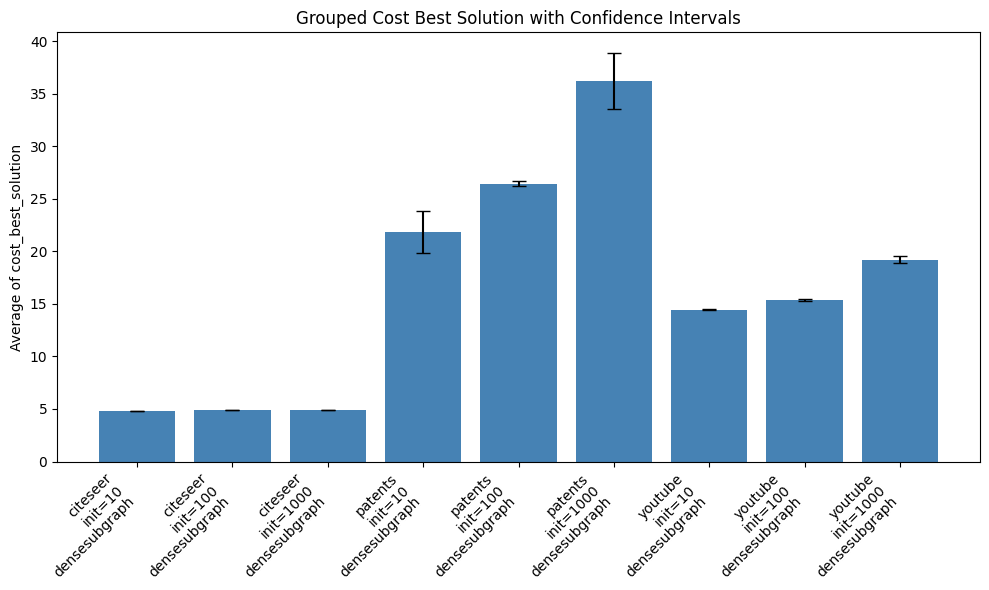

In [14]:
import matplotlib.pyplot as plt
import numpy as np

df = original_df[original_df.objective_function == "densesubgraph"]

# Y-axis values
y = df['AVERAGE of cost_best_solution']

# Asymmetric error bars: top and bottom distances from the average
yerr = [
   df['confidence_interval'],
   df['confidence_interval']
]

# X-axis labels: grouped by graph / initial / objective
labels = df.apply(
    lambda row: f"{row['graph_name']}\ninit={row['initial_solutions']}\n{row['objective_function']}",
    axis=1
)

# X positions
x = np.arange(len(df))

# Plot
fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(x, y, yerr=yerr, capsize=5, color='steelblue')

# Axis settings
ax.set_ylabel("Average of cost_best_solution")
ax.set_title("Grouped Cost Best Solution with Confidence Intervals")
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45, ha='right')

plt.tight_layout()
plt.show()
